1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# better visualization style
plt.style.use("ggplot")

2. Load the dataset

In [2]:
df = pd.read_csv("study_eu_programs_with_ranking.csv")

3. Basic dataset overview

In [3]:
print("Shape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
df.head()

Shape of dataset:
(10203, 8)

Columns:
Index(['university_name', 'program_name', 'degree', 'tuition_fee_usd_total',
       'program_duration_year', 'global_ranking', 'university_location',
       'url'],
      dtype='str')

First 5 rows:


,university_name,program_name,degree,tuition_fee_usd_total,program_duration_year,global_ranking,university_location,url
0,University of Szeged,Agricultural Engineering,BSc,18058.0,NaN,646.0,"Szeged, Hungary",https://www.study.eu/university/university-of-...
1,University of Helsinki,"Agricultural, Environmental and Resource Econo...",MSc,35179.0,2.0,79.0,"Helsinki, Finland",https://www.study.eu/university/university-of-...
2,University of Helsinki,Agricultural Sciences,MSc,35179.0,2.0,79.0,"Helsinki, Finland",https://www.study.eu/university/university-of-...
3,TBS Education,AI-Driven Digital Marketing & Analytics (Barce...,Master,22866.0,1.0,NaN,"Barcelona, Spain",https://www.study.eu/university/tbs-education/...
4,University of Szeged,American Studies,MA,8912.0,NaN,646.0,"Szeged, Hungary",https://www.study.eu/university/university-of-...


4. Data types and missing values

In [4]:
df.info()

print("\nMissing values per column:")
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10203 entries, 0 to 10202
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   university_name        10203 non-null  str    
 1   program_name           10203 non-null  str    
 2   degree                 10203 non-null  str    
 3   tuition_fee_usd_total  3010 non-null   float64
 4   program_duration_year  8130 non-null   float64
 5   global_ranking         8031 non-null   float64
 6   university_location    10203 non-null  str    
 7   url                    10203 non-null  str    
dtypes: float64(3), str(5)
memory usage: 2.3 MB

Missing values per column:


university_name             0
program_name                0
degree                      0
tuition_fee_usd_total    7193
program_duration_year    2073
global_ranking           2172
university_location         0
url                         0
dtype: int64

5. Check duplicates

In [5]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


Descriptive statistics (Numerical columns)

In [6]:
df.describe()


,tuition_fee_usd_total,program_duration_year,global_ranking
count,3010.000000,8130.000000,8031.000000
mean,47543.702990,2.380109,1766.844727
std,37108.070742,1.110348,3171.538121
min,121.000000,0.500000,3.000000
25%,19413.000000,1.000000,291.000000
50%,31619.000000,2.000000,627.000000
75%,71042.000000,3.000000,1359.000000
max,375248.000000,10.000000,22851.000000


7.Univariate Analysis (Single column analysis)

7.1 Tuition Fees Distribution

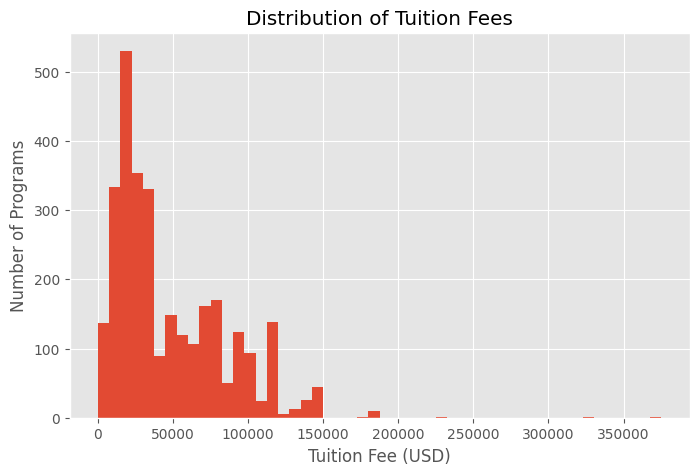

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['tuition_fee_usd_total'], bins=50)
plt.title("Distribution of Tuition Fees")
plt.xlabel("Tuition Fee (USD)")
plt.ylabel("Number of Programs")
plt.show()

7.2 Program Duration Distribution

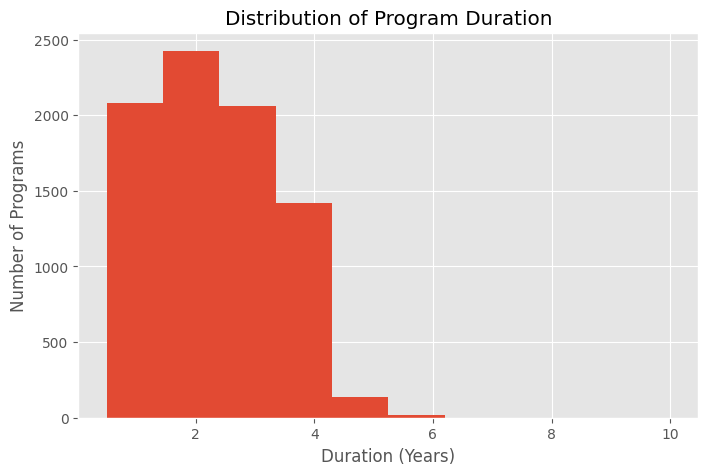

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['program_duration_year'], bins=10)
plt.title("Distribution of Program Duration")
plt.xlabel("Duration (Years)")
plt.ylabel("Number of Programs")
plt.show()

7.3 Global Ranking Distribution

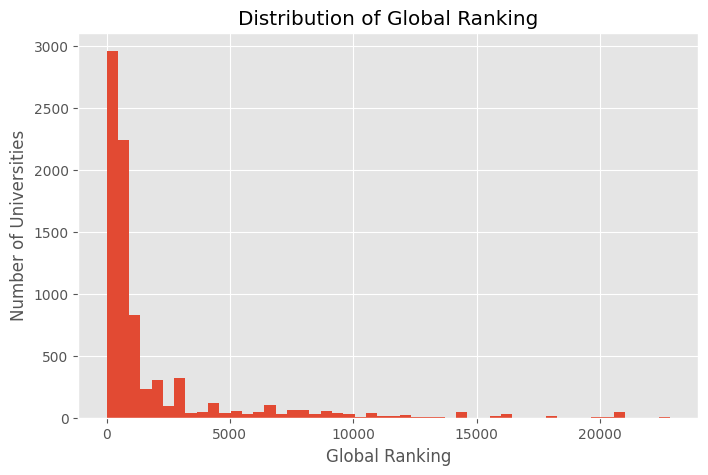

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df['global_ranking'], bins=50)
plt.title("Distribution of Global Ranking")
plt.xlabel("Global Ranking")
plt.ylabel("Number of Universities")
plt.show()

8. Categorical Analysis


8.1 Most common degrees

In [10]:
df['degree'].value_counts()

degree
MSc            2475
Master         1936
MA              902
Bachelor        787
BSc (Hons)      773
BA (Hons)       734
PhD             684
BSc             441
BA              354
M (UG)          136
MA (UG)         126
MPhil           103
MBA              85
BEng             79
LLM              72
BEng (Hons)      69
MEng             56
MRes             53
BBA              52
B+M              47
DBA              33
MEd              25
MLitt            23
MSci             21
MFA              20
AdvM             20
LLB (Hons)       16
PgDip            13
MArch            12
MMus             10
MSc (UG)          7
MDes              5
MPhys             4
MChem (UG)        4
BDS               4
BMus              3
MPA               3
LLB               3
MSt               3
GradDip           2
MEng (UG)         2
MSc (Tech)        1
MChem             1
MEng (Hons)       1
BSc+MSc           1
MTh               1
BEd (Hons)        1
Name: count, dtype: int64

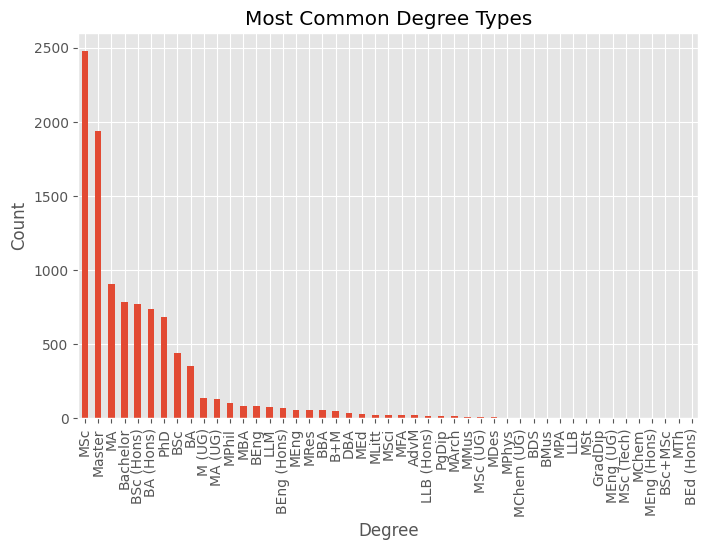

In [11]:
df['degree'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Most Common Degree Types")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()

8.2 Most common countries (location)

In [12]:
df['university_location'].value_counts().head(15)

university_location
London, United Kingdom        900
Dublin, Ireland               450
Canterbury, United Kingdom    215
Amsterdam, Netherlands        176
Colchester, United Kingdom    172
Stockholm, Sweden             168
Aberdeen, United Kingdom      167
Bangor, United Kingdom        159
Cardiff, United Kingdom       158
Prague, Czech Republic        140
Edinburgh, United Kingdom     140
Kaunas, Lithuania             132
Galway, Ireland               130
Keele, United Kingdom         129
Cork, Ireland                 127
Name: count, dtype: int64

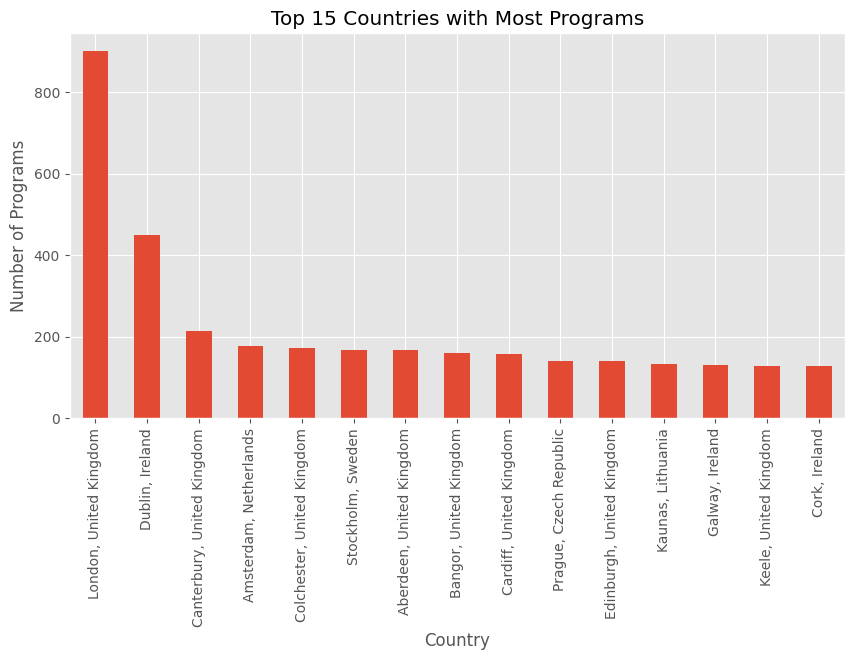

In [13]:
df['university_location'].value_counts().head(15).plot(kind='bar', figsize=(10,5))
plt.title("Top 15 Countries with Most Programs")
plt.xlabel("Country")
plt.ylabel("Number of Programs")
plt.show()

8.3 Universities with most programs

In [14]:
df['university_name'].value_counts().head(10)

university_name
University of Kent                   256
University of Essex                  172
University College Dublin (UCD)      171
University of Aberdeen               169
Bangor University                    159
Atlantic Technological University    153
Cardiff University                   153
University of Edinburgh              137
Queen Mary University of London      136
Keele University                     129
Name: count, dtype: int64

9. Bivariate Analysis (Relationships)

9.1 Tuition fee vs Ranking

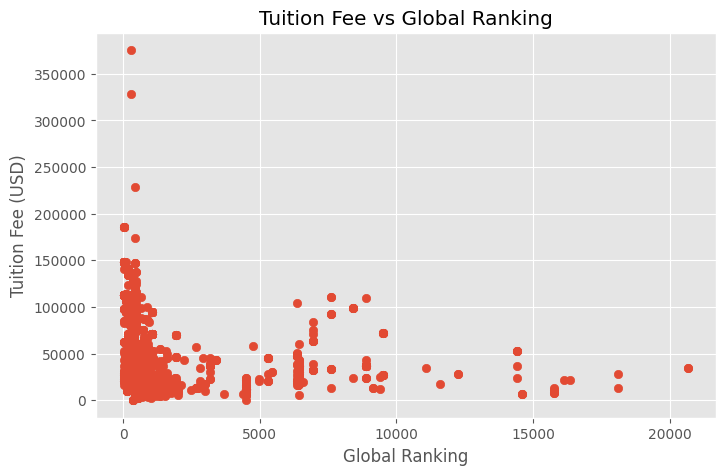

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df['global_ranking'], df['tuition_fee_usd_total'])
plt.title("Tuition Fee vs Global Ranking")
plt.xlabel("Global Ranking")
plt.ylabel("Tuition Fee (USD)")
plt.show()

9.2 Tuition fee vs Program Duration


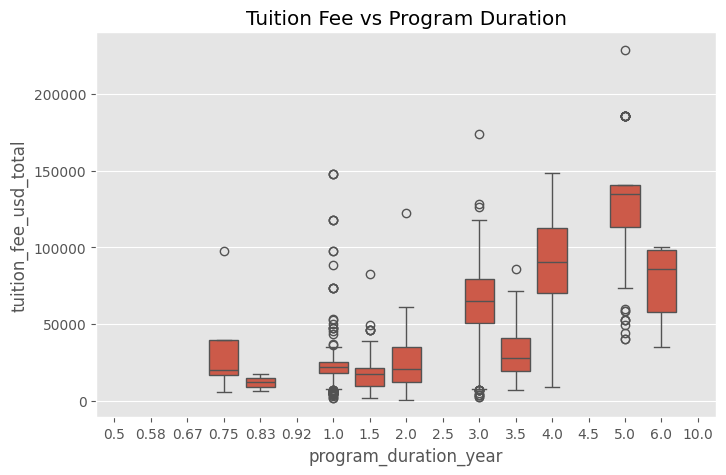

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='program_duration_year', y='tuition_fee_usd_total', data=df)
plt.title("Tuition Fee vs Program Duration")
plt.show()

9.3 Tuition fee by Country

In [17]:
country_fees = df.groupby('university_location')['tuition_fee_usd_total'].mean().sort_values(ascending=False)
country_fees.head(10)

university_location
Edinburgh, United Kingdom                      127643.310606
Segovia, Spain                                 111870.200000
Geneva, Switzerland + 1 more campus            104131.000000
Cardiff, United Kingdom                         98047.158940
Dundee, United Kingdom                          92213.684211
Lancaster, United Kingdom                       84616.666667
Newcastle upon Tyne, United Kingdom             83958.666667
Aberdeen, United Kingdom                        79861.244898
Uxbridge, United Kingdom                        77025.561905
United Kingdom – programme delivered online     70930.000000
Name: tuition_fee_usd_total, dtype: float64

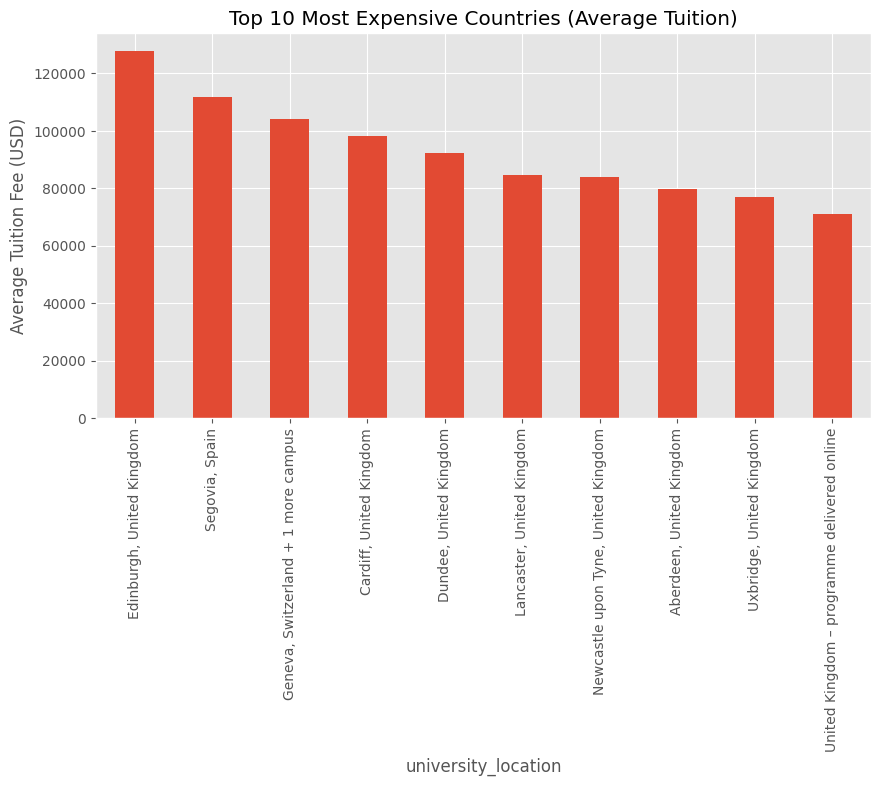

In [18]:
country_fees.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Most Expensive Countries (Average Tuition)")
plt.ylabel("Average Tuition Fee (USD)")
plt.show()

10. Outlier Detection

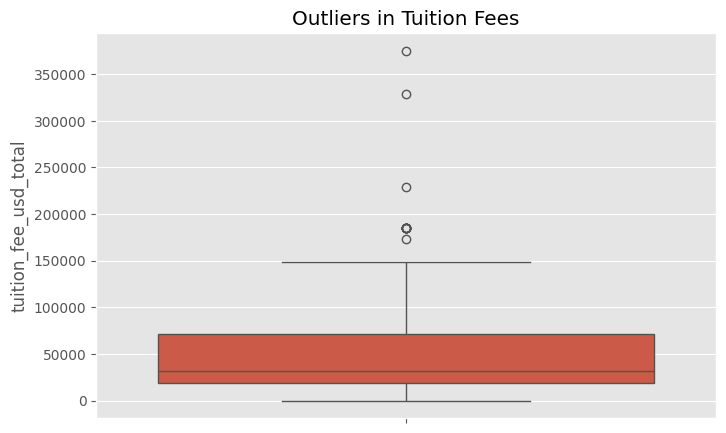

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(df['tuition_fee_usd_total'])
plt.title("Outliers in Tuition Fees")
plt.show()

11. Correlation Analysis

In [20]:
correlation = df.corr(numeric_only=True)
correlation

,tuition_fee_usd_total,program_duration_year,global_ranking
tuition_fee_usd_total,1.000000,0.699798,-0.209108
program_duration_year,0.699798,1.000000,0.035061
global_ranking,-0.209108,0.035061,1.000000


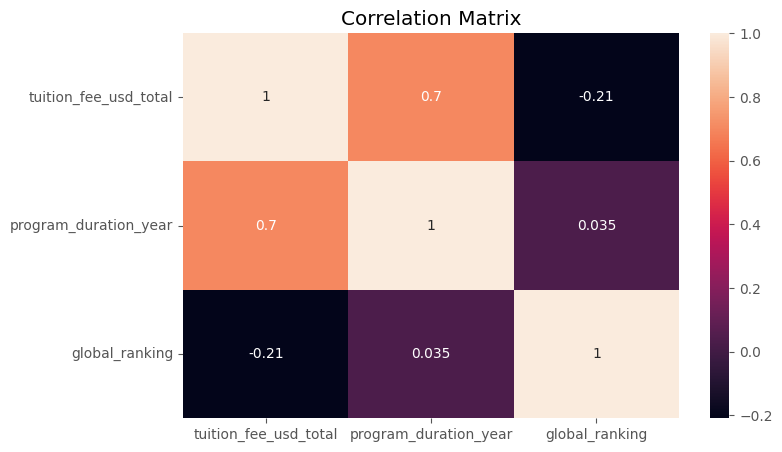

In [21]:
plt.figure(figsize=(8,5))
sns.heatmap(correlation, annot=True)
plt.title("Correlation Matrix")
plt.show()

NLP

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('study_eu_programs_with_ranking.csv')

print("Starting Data Processing...")

def standardize_degree(text):
    text = str(text).lower()
    if any(word in text for word in ['bachelor', 'bsc', 'b.a', 'bs']):
        return "Bachelor's"
    elif any(word in text for word in ['master', 'msc', 'mba', 'm.a', 'ms']):
        return "Master's"
    elif any(word in text for word in ['phd', 'doctor']):
        return "Doctorate"
    else:
        return "Other"

def tag_subject(title):
    title = str(title).lower()
    if any(w in title for w in ['computer', 'software', 'data', 'ai', 'cyber', 'it', 'tech', 'machine', 'information']):
        return "💻 Tech & IT"
    elif any(w in title for w in ['business', 'management', 'finance', 'marketing', 'mba', 'economics', 'admin']):
        return "📊 Business & Management"
    elif any(w in title for w in ['engineer', 'mechanic', 'civil', 'electric', 'aerospace']):
        return "⚙️ Engineering"
    elif any(w in title for w in ['health', 'med', 'nurs', 'bio', 'psych', 'pharm']):
        return "🧬 Health & Science"
    elif any(w in title for w in ['art', 'design', 'history', 'law', 'sociology', 'music', 'culture']):
        return "🎨 Arts & Humanities"
    else:
        return "📚 General/Other"

df['clean_degree_type'] = df['degree'].apply(standardize_degree)
df['subject_tag'] = df['program_name'].apply(tag_subject)
print("NLP: Degrees standardized and Subjects tagged!")

ml_df = df.dropna(subset=['tuition_fee_usd_total', 'global_ranking']).copy()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(ml_df[['tuition_fee_usd_total', 'global_ranking']])

kmeans = KMeans(n_clusters=4, random_state=42)
ml_df['Value_Tier_ID'] = kmeans.fit_predict(scaled_features)

cluster_stats = ml_df.groupby('Value_Tier_ID')['tuition_fee_usd_total'].mean().sort_values()

tier_names = ['🟢 Budget-Friendly', '🟡 Standard Value', '🟠 Premium Programs', '🔴 Elite/Expensive']
tier_mapping = {cluster_id: name for cluster_id, name in zip(cluster_stats.index, tier_names)}

ml_df['Value_Tier_Name'] = ml_df['Value_Tier_ID'].map(tier_mapping)

df = df.merge(ml_df[['url', 'Value_Tier_Name']], on='url', how='left')

df['Value_Tier_Name'] = df['Value_Tier_Name'].fillna('⚪ Unranked/Missing Data')

print("ML: Programs successfully clustered and named!")

df.to_csv('study_eu_ready_for_dashboard.csv', index=False)
print("Success! Saved as 'study_eu_ready_for_dashboard.csv'")

Starting Data Processing...
NLP: Degrees standardized and Subjects tagged!
ML: Programs successfully clustered and named!
Success! Saved as 'study_eu_ready_for_dashboard.csv'
